In [1]:
import pandas as pd

# load all 4 etsy files and combine into one
df1 = pd.read_csv('data/etsy_data1.csv')
df2 = pd.read_csv('data/etsy_data2.csv')
df3 = pd.read_csv('data/etsy_data3.csv')
df4 = pd.read_csv('data/etsy_data4.csv')

df_etsy = pd.concat([df1, df2, df3, df4], ignore_index=True)

print(f"Total rows: {len(df_etsy)}")
print(f"Columns: {df_etsy.columns.tolist()}")
print(df_etsy.head())

Total rows: 256
Columns: ['web_scraper_order', 'web_scraper_start_url', 'title', 'data', 'data2', 'name', 'data3', 'data4', 'data5', 'title2', 'data6', 'data7', 'data8', 'data9', 'data10', 'data11', 'data12', 'name2', 'data13', 'data14', 'data15', 'price', 'data16', 'title3', 'data17', 'data18', 'data19', 'data20', 'data21', 'data22', 'image', 'data23', 'pagination']
  web_scraper_order                              web_scraper_start_url  \
0      1780573623-1  https://www.etsy.com/search?q=authentic+kashmi...   
1      1780573623-2  https://www.etsy.com/search?q=authentic+kashmi...   
2      1780573623-3  https://www.etsy.com/search?q=authentic+kashmi...   
3      1780573623-4  https://www.etsy.com/search?q=authentic+kashmi...   
4      1780573623-5  https://www.etsy.com/search?q=authentic+kashmi...   

                                               title                    data  \
0  100% Authentic Pure Kashmiri Pashmina Shawl, H...  By BeighCashmereShawls   
1  100% Authentic Pure Ka

In [2]:
print(df1.shape)
print(df1.dropna(how='all').shape)

(64, 31)
(64, 31)


In [3]:
# drop empty rows from all files
df1 = df1.dropna(how='all')
df2 = df2.dropna(how='all')
df3 = df3.dropna(how='all')
df4 = df4.dropna(how='all')

# combine all etsy files
df_etsy = pd.concat([df1, df2, df3, df4], ignore_index=True)

print(f"Total Etsy rows: {len(df_etsy)}")
print(f"Columns: {df_etsy.columns.tolist()}")
print(df_etsy.head())

Total Etsy rows: 256
Columns: ['web_scraper_order', 'web_scraper_start_url', 'title', 'data', 'data2', 'name', 'data3', 'data4', 'data5', 'title2', 'data6', 'data7', 'data8', 'data9', 'data10', 'data11', 'data12', 'name2', 'data13', 'data14', 'data15', 'price', 'data16', 'title3', 'data17', 'data18', 'data19', 'data20', 'data21', 'data22', 'image', 'data23', 'pagination']
  web_scraper_order                              web_scraper_start_url  \
0      1780573623-1  https://www.etsy.com/search?q=authentic+kashmi...   
1      1780573623-2  https://www.etsy.com/search?q=authentic+kashmi...   
2      1780573623-3  https://www.etsy.com/search?q=authentic+kashmi...   
3      1780573623-4  https://www.etsy.com/search?q=authentic+kashmi...   
4      1780573623-5  https://www.etsy.com/search?q=authentic+kashmi...   

                                               title                    data  \
0  100% Authentic Pure Kashmiri Pashmina Shawl, H...  By BeighCashmereShawls   
1  100% Authentic Pu

In [4]:
df_etsy_clean = df_etsy[['title', 'name', 'data3', 'title2', 'price', 'image']].copy()
df_etsy_clean.columns = ['title', 'shop', 'sales', 'rating', 'price', 'image']

print(df_etsy_clean.head())
print(f"\nTotal: {len(df_etsy_clean)}")
print(f"\nPrice sample: {df_etsy_clean['price'].head(10).tolist()}")

                                               title                 shop  \
0  100% Authentic Pure Kashmiri Pashmina Shawl, H...  BeighCashmereShawls   
1  100% Authentic Pure Kashmiri Pashmina Shawl, H...  BeighCashmereShawls   
2  100% Authentic Pure Kashmiri Pashmina Shawl, H...  BeighCashmereShawls   
3  100% Authentic Pure Kashmiri Pashmina Shawl, H...  BeighCashmereShawls   
4  Natural Undyed Hand Embroidered Pure Pashmina ...  BeighCashmereShawls   

    sales  rating          price  \
0  22,178     5.0  Free delivery   
1  24,265     5.0  Free delivery   
2  22,178     5.0  Free delivery   
3  22,178     5.0  Free delivery   
4  38,738     5.0  Free delivery   

                                               image  
0  https://i.etsystatic.com/60706692/c/1684/1684/...  
1  https://i.etsystatic.com/60706692/r/il/5e1707/...  
2  https://i.etsystatic.com/60706692/c/1682/1682/...  
3  https://i.etsystatic.com/60706692/c/1684/1684/...  
4  https://i.etsystatic.com/60706692/c/1792/1

In [5]:
# search all columns for rupee symbol or numbers that look like prices
for col in df_etsy.columns:
    sample = df_etsy[col].dropna().head(3).tolist()
    print(f"{col}: {sample}")

web_scraper_order: ['1780573623-1', '1780573623-2', '1780573623-3']
web_scraper_start_url: ['https://www.etsy.com/search?q=authentic+kashmiri+pashmina+shawl&instant_download=false', 'https://www.etsy.com/search?q=authentic+kashmiri+pashmina+shawl&instant_download=false', 'https://www.etsy.com/search?q=authentic+kashmiri+pashmina+shawl&instant_download=false']
title: ['100% Authentic Pure Kashmiri Pashmina Shawl, Handwoven Natural Beige Cashmere Wrap, Ultra-Soft |KPAS Certified', '100% Authentic Pure Kashmiri Pashmina Shawl, Handwoven Amethyst Purple and Slate Gray, Dual Gradient Ombre Scarf (KPAS Certified)', '100% Authentic Pure Kashmiri Pashmina Shawl, Handwoven Sage Green Wrap, Ultra-Soft |KPAS Certified']
data: ['By BeighCashmereShawls', 'By BeighCashmereShawls', 'By BeighCashmereShawls']
data2: ['From shop BeighCashmereShawls', 'From shop BeighCashmereShawls', 'From shop BeighCashmereShawls']
name: ['BeighCashmereShawls', 'BeighCashmereShawls', 'BeighCashmereShawls']
data3: ['22,1

In [6]:
df_etsy_clean = df_etsy[['title', 'name', 'data3', 'title2', 'data5', 'data6', 'data8', 'image']].copy()
df_etsy_clean.columns = ['title', 'shop', 'sales', 'rating', 'sale_price', 'original_price', 'discount', 'image']

# clean prices - remove commas and convert to numbers
df_etsy_clean['sale_price'] = df_etsy_clean['sale_price'].str.replace(',', '').str.strip()
df_etsy_clean['sale_price'] = pd.to_numeric(df_etsy_clean['sale_price'], errors='coerce')

df_etsy_clean['original_price'] = df_etsy_clean['original_price'].str.replace(',', '').str.strip()
df_etsy_clean['original_price'] = pd.to_numeric(df_etsy_clean['original_price'], errors='coerce')

# clean sales count
df_etsy_clean['sales'] = df_etsy_clean['sales'].str.replace(',', '').str.strip()
df_etsy_clean['sales'] = pd.to_numeric(df_etsy_clean['sales'], errors='coerce')

# drop rows with no price
df_etsy_clean = df_etsy_clean.dropna(subset=['sale_price']).reset_index(drop=True)

print(df_etsy_clean.head())
print(f"\nTotal: {len(df_etsy_clean)}")
print(f"Price range: ₹{df_etsy_clean['sale_price'].min()} — ₹{df_etsy_clean['sale_price'].max()}")
print(f"Average: ₹{df_etsy_clean['sale_price'].mean():.0f}")

                                               title                shop  \
0  Pashmina Shawl with Intricate Bird and Floral ...  TRENDINGWAVESCRAFT   
1  Authentic kashmiri pashmina handmade tilla sha...         Houseofmirs   
2  Hand Embroidered on pure Pashmina Shawl: Kashm...  TooshPashminashawl   
3  Multi Embroidered Pashmina Shawl | Floral Aari...  TRENDINGWAVESCRAFT   
4  Luxury Embroidered Pashmina Shawl, Ivory Kashm...  TRENDINGWAVESCRAFT   

   sales  rating  sale_price  original_price   discount  \
0    NaN     4.2      6761.0         13522.0  (50% off)   
1    NaN     4.9     43825.0         62608.0  (30% off)   
2    NaN     4.7     16159.0         20199.0  (20% off)   
3    NaN     4.2      6160.0         12320.0  (50% off)   
4    NaN     4.2      7061.0         14123.0  (50% off)   

                                               image  
0  https://i.etsystatic.com/63337261/r/il/dae278/...  
1  https://i.etsystatic.com/23761665/r/il/d3be9f/...  
2  https://i.etsystatic

In [7]:
# save
df_etsy_clean.to_csv('data/etsy_clean.csv', index=False)
print("Saved!")

# market analysis
print("\n=== ETSY MARKET SUMMARY ===")
print(f"Total products: {len(df_etsy_clean)}")
print(f"Total shops: {df_etsy_clean['shop'].nunique()}")

print("\nTop 5 shops by listings:")
print(df_etsy_clean['shop'].value_counts().head())

print("\nAverage sale price by shop (top 8):")
print(df_etsy_clean.groupby('shop')['sale_price'].mean().sort_values(ascending=False).head(8))

print("\nAverage discount:")
print(df_etsy_clean['discount'].value_counts().head())

Saved!

=== ETSY MARKET SUMMARY ===
Total products: 125
Total shops: 31

Top 5 shops by listings:
shop
JKSowling             29
TRENDINGWAVESCRAFT    27
Shawsans              12
TooshPashminashawl     6
ShawsanShop            5
Name: count, dtype: int64

Average sale price by shop (top 8):
shop
Indusweavers           209658.000000
GiftedHandsIN          156304.000000
PashminaVogue          106875.000000
BeighCashmereShawls     81781.000000
Kashmina786             55629.333333
Houseofmirs             43825.000000
Noorpashmina            29901.000000
HouseofArtiglo          26045.000000
Name: sale_price, dtype: float64

Average discount:
discount
(50% off)    48
(20% off)    35
(25% off)     9
(45% off)     5
(35% off)     4
Name: count, dtype: int64


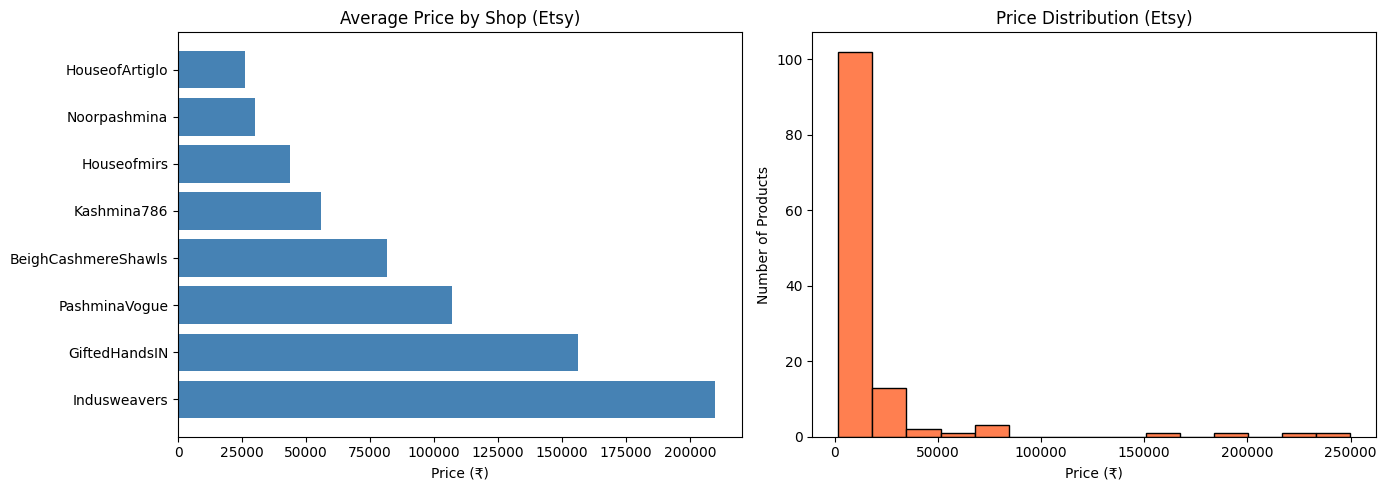

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# top shops by average price
shop_prices = df_etsy_clean.groupby('shop')['sale_price'].mean().sort_values(ascending=False).head(8)
axes[0].barh(shop_prices.index, shop_prices.values, color='steelblue')
axes[0].set_title('Average Price by Shop (Etsy)')
axes[0].set_xlabel('Price (₹)')

# price distribution
axes[1].hist(df_etsy_clean['sale_price'], bins=15, color='coral', edgecolor='black')
axes[1].set_title('Price Distribution (Etsy)')
axes[1].set_xlabel('Price (₹)')
axes[1].set_ylabel('Number of Products')

plt.tight_layout()
plt.show()


In [9]:
competitors = ['Noorpashmina', 'HouseofArtiglo', 'BeighCashmereShawls', 'Kashmina786']

df_comp = df_etsy_clean[df_etsy_clean['shop'].isin(competitors)]

print(df_comp[['shop', 'title', 'sale_price', 'original_price', 'discount', 'rating']].to_string())

                    shop                                                                                                                                     title  sale_price  original_price   discount  rating
14           Kashmina786                                                                        Kashmiri Wool Shawl: Embroidered Border, Lightweight Pashmina Feel     10218.0         12021.0  (15% off)     4.8
16        HouseofArtiglo  Authentic 100 % Pashmina Wedding Shawl, Black & Gold, Sozni Hand Embroidery, Handwoven Kashmiri Artisan Scarf, Luxury Wrap, Gift for Her     26045.0         40069.0  (35% off)     5.0
18        HouseofArtiglo    Authentic 100 % Pashmina Wedding Shawl, Blush Pink, Sozni Hand Embroidery, Handwoven Kashmiri Artisan Scarf, Luxury Wrap, Gift for Her     26045.0         40069.0  (35% off)     5.0
45           Kashmina786                                                                         Luxury Pashmina Shawl: Kashmiri Sozni Embroidery, Natural Jamaw

In [12]:
amazon_cols = df_amazon_clean[['title', 'brand', 'price', 'image', 'source']].copy()
amazon_cols['rating'] = None  # amazon data has no rating column so we add empty one

etsy_cols = df_etsy_clean[['title', 'shop', 'sale_price', 'rating', 'image', 'source']].copy()
etsy_cols.columns = ['title', 'brand', 'price', 'rating', 'image', 'source']

df_master = pd.concat([etsy_cols, amazon_cols], ignore_index=True)

print(f"Total products: {len(df_master)}")
print(f"From Etsy: {len(df_master[df_master['source']=='Etsy'])}")
print(f"From Amazon.ae: {len(df_master[df_master['source']=='Amazon.ae'])}")
print(df_master.head())


Total products: 173
From Etsy: 125
From Amazon.ae: 48
                                               title               brand  \
0  Pashmina Shawl with Intricate Bird and Floral ...  TRENDINGWAVESCRAFT   
1  Authentic kashmiri pashmina handmade tilla sha...         Houseofmirs   
2  Hand Embroidered on pure Pashmina Shawl: Kashm...  TooshPashminashawl   
3  Multi Embroidered Pashmina Shawl | Floral Aari...  TRENDINGWAVESCRAFT   
4  Luxury Embroidered Pashmina Shawl, Ivory Kashm...  TRENDINGWAVESCRAFT   

     price rating                                              image source  
0   6761.0    4.2  https://i.etsystatic.com/63337261/r/il/dae278/...   Etsy  
1  43825.0    4.9  https://i.etsystatic.com/23761665/r/il/d3be9f/...   Etsy  
2  16159.0    4.7  https://i.etsystatic.com/25734426/r/il/779b36/...   Etsy  
3   6160.0    4.2  https://i.etsystatic.com/63337261/r/il/d78297/...   Etsy  
4   7061.0    4.2  https://i.etsystatic.com/63337261/r/il/9498b3/...   Etsy  


In [11]:
print(df_amazon_clean.columns.tolist())

['brand', 'title', 'reviews', 'price', 'image', 'source']


In [13]:
df_master.to_csv('data/master_dataset.csv', index=False)
print("Master dataset saved!")

# final summary
print(f"\n=== MASTER DATASET SUMMARY ===")
print(f"Total products: {len(df_master)}")
print(f"Total brands/shops: {df_master['brand'].nunique()}")
print(f"\nPrice range (all platforms):")
print(f"Min: ₹{df_master['price'].min():.0f}")
print(f"Max: ₹{df_master['price'].max():.0f}")
print(f"Average: ₹{df_master['price'].mean():.0f}")
print(f"\nProducts per platform:")
print(df_master['source'].value_counts())


Master dataset saved!

=== MASTER DATASET SUMMARY ===
Total products: 173
Total brands/shops: 51

Price range (all platforms):
Min: ₹19
Max: ₹249965
Average: ₹14508

Products per platform:
source
Etsy         125
Amazon.ae     48
Name: count, dtype: int64


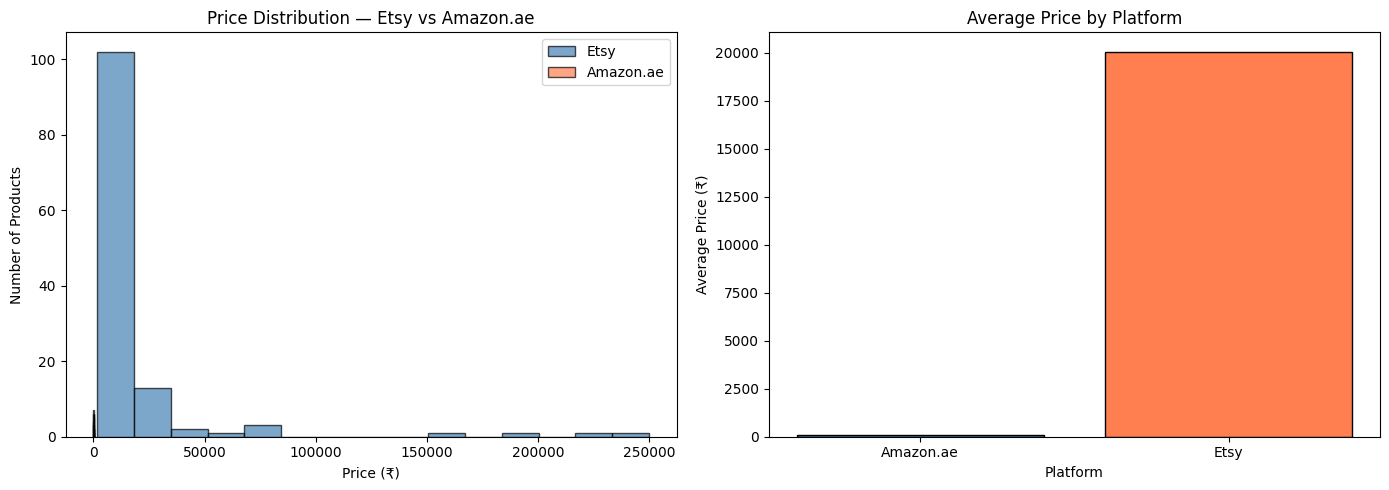

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# price distribution by platform
etsy_prices = df_master[df_master['source']=='Etsy']['price']
amazon_prices = df_master[df_master['source']=='Amazon.ae']['price']

axes[0].hist(etsy_prices, bins=15, alpha=0.7, color='steelblue', label='Etsy', edgecolor='black')
axes[0].hist(amazon_prices, bins=15, alpha=0.7, color='coral', label='Amazon.ae', edgecolor='black')
axes[0].set_title('Price Distribution — Etsy vs Amazon.ae')
axes[0].set_xlabel('Price (₹)')
axes[0].set_ylabel('Number of Products')
axes[0].legend()

# average price per platform
avg_prices = df_master.groupby('source')['price'].mean()
axes[1].bar(avg_prices.index, avg_prices.values, color=['steelblue', 'coral'], edgecolor='black')
axes[1].set_title('Average Price by Platform')
axes[1].set_xlabel('Platform')
axes[1].set_ylabel('Average Price (₹)')

plt.tight_layout()
plt.show()